# NOAA TAO/TRITON ENSO Analysis

This notebook provides a reusable workflow for analysing ENSO related observational datasets from the NOAA TAO/TRITON array.

The analysis focuses on Sea Surface Temperature (SST) and the 20°C Isotherm Depth (Z20), two key variables associated with ENSO dynamics and the Recharge Oscillator framework.

## Objectives

- Load, clean and preprocess NOAA datasets.
- Assess data quality and temporal coverage.
- Perform exploratory statistical analyses.
- Investigate dominant variability and spectral characteristics.
- Compare behaviour across multiple locations.
- Generate reproducible figures and analysis summaries.
- Prepare datasets for subsequent ENSO and NGRC studies.

In [1]:
from pathlib import Path
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import periodogram, find_peaks

In [2]:
# Output directories

OUTPUT_DIR = Path("../outputs")

IMAGE_DIR = OUTPUT_DIR / "images" / "enso"

LOG_DIR = OUTPUT_DIR / "logs"

LOG_FILE = LOG_DIR / "analysis_report.txt"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def clean_file(filename, variable_name="value"):

    records=[]

    with gzip.open(filename,"rt") as f:
        for line in f:

            parts=line.split()

            if len(parts)!=4:
                continue

            try:
                records.append([
                    parts[0],
                    parts[1],
                    float(parts[2]),
                    int(parts[3])
                ])

            except ValueError:
                continue

    df=pd.DataFrame(
        records,
        columns=["date","time",variable_name,"quality"]
    )

    df["date"]=pd.to_datetime(
        df["date"],
        format="%Y%m%d"
    )

    # Store metadata for reporting and subsequent analyses
    details={
        "file":Path(filename).name,
        "variable":variable_name.upper(),
        "observations":len(df),
        "start":df["date"].min().date(),
        "end":df["date"].max().date(),
        "sampling":"5-day",
        "quality":df["quality"].value_counts().to_dict()
    }

    return df, details

In [4]:
def prepare_enso_data(sst_file, z20_file):

    sst, _ = clean_file(sst_file, "sst")
    z20, _ = clean_file(z20_file, "z20")

    sst_missing = (sst["sst"] == -9.99).sum()
    z20_missing = (z20["z20"] == -9.99).sum()

    sst["sst"] = sst["sst"].replace(-9.99, np.nan)
    z20["z20"] = z20["z20"].replace(-9.99, np.nan)

    enso = sst[["date", "sst"]].merge(
        z20[["date", "z20"]],
        on="date",
        how="inner"
    )

    rows_before = len(enso)

    enso = enso.dropna()

    # Create anomaly series for subsequent analyses
    enso["sst_anom"] = enso["sst"] - enso["sst"].mean()
    enso["z20_anom"] = enso["z20"] - enso["z20"].mean()

    details = {
    "sst_missing": sst_missing,
    "z20_missing": z20_missing,
    "merged_observations": rows_before,
    "observations": len(enso),
    "start": enso["date"].min().date(),
    "end": enso["date"].max().date()
    }

    return enso, details

In [5]:
enso, details = prepare_enso_data(
    "data/sst/sst0n155w_5day.ascii.gz",
    "data/z20/iso0n155w_5day.ascii.gz"
)

details

{'sst_missing': np.int64(1),
 'z20_missing': np.int64(32),
 'merged_observations': 1875,
 'observations': 1844,
 'start': datetime.date(1991, 7, 22),
 'end': datetime.date(2026, 6, 7)}

In [6]:
def plot_time_series(enso, name="enso", save=True):

    # Visualise SST and Z20 temporal evolution
    fig, ax = plt.subplots(
        2, 1,
        figsize=(12, 8),
        sharex=True
    )

    ax[0].plot(enso["date"], enso["sst"])
    ax[0].set_title("Sea Surface Temperature (SST)")
    ax[0].set_ylabel("Temperature (°C)")
    ax[0].grid(alpha=0.3)

    ax[1].plot(enso["date"], enso["z20"])
    ax[1].set_title("20°C Isotherm Depth (Z20)")
    ax[1].set_ylabel("Depth (m)")
    ax[1].set_xlabel("Year")
    ax[1].grid(alpha=0.3)

    plt.tight_layout()

    if save:
        plt.savefig(
            IMAGE_DIR / f"{name}_time_series.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [7]:
def check_gaps(enso, threshold_days=30):

    delta = enso.sort_values("date")["date"].diff()

    gaps = enso.loc[
        delta > pd.Timedelta(days=threshold_days),
        ["date"]
    ].copy()

    if len(gaps):
        gaps["gap_days"] = delta[
            delta > pd.Timedelta(days=threshold_days)
        ].dt.days.values

    return gaps

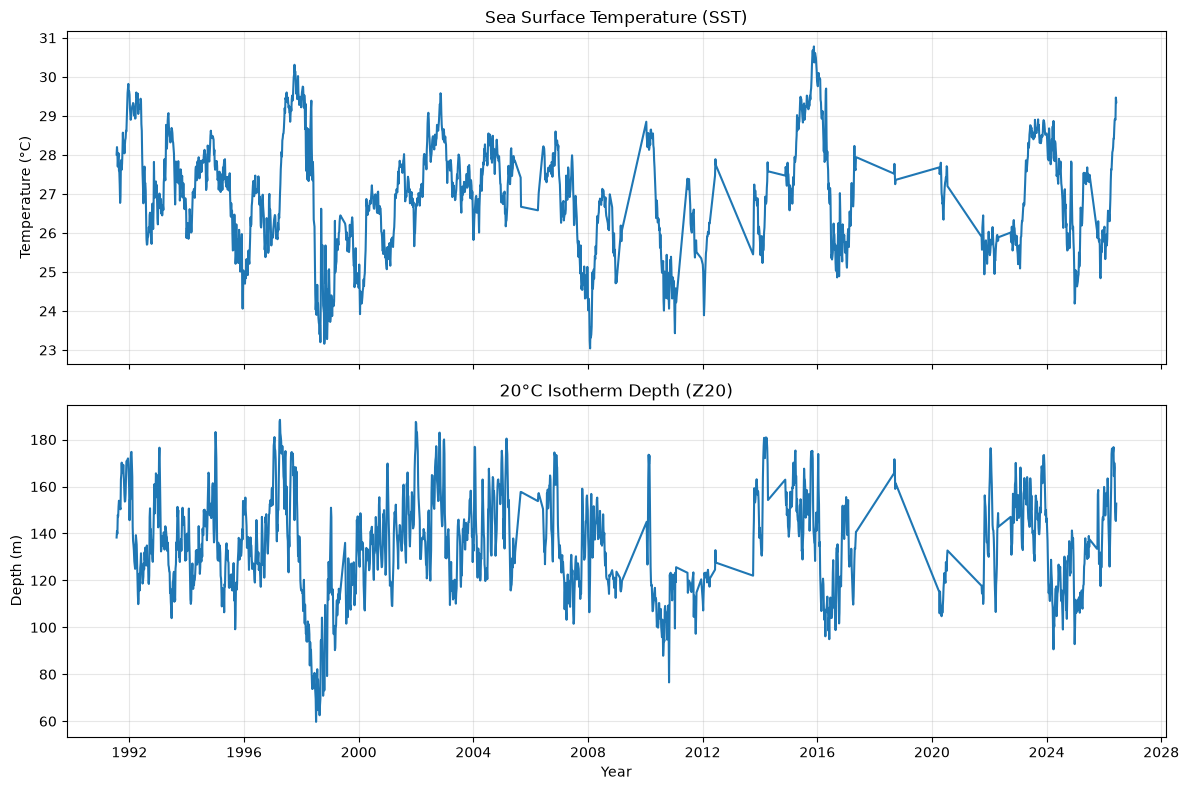

,date,gap_days
571,1999-07-12,60
1005,2005-08-26,70
1007,2006-04-03,215
1010,2006-06-07,55
1198,2009-02-12,45


In [8]:
plot_time_series(enso, name="0n155w")

gaps = check_gaps(enso)

gaps.head()

In [9]:
def plot_distributions(enso, name="enso", save=True):

    # Visualise the distributions of SST and Z20
    fig, ax = plt.subplots(
        1, 2,
        figsize=(12, 4)
    )

    ax[0].hist(enso["sst"], bins=30)
    ax[0].set_title("Distribution of SST")
    ax[0].set_xlabel("SST (°C)")
    ax[0].set_ylabel("Frequency")
    ax[0].grid(alpha=0.3)

    ax[1].hist(enso["z20"], bins=30)
    ax[1].set_title("Distribution of Z20")
    ax[1].set_xlabel("Z20 (m)")
    ax[1].set_ylabel("Frequency")
    ax[1].grid(alpha=0.3)

    plt.tight_layout()

    if save:
        plt.savefig(
            IMAGE_DIR / f"{name}_distribution.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [10]:
def plot_scatter(enso, name="enso", save=True):

    # Examine the relationship between SST and Z20
    corr = enso["sst"].corr(enso["z20"])

    plt.figure(figsize=(6, 6))

    plt.scatter(
        enso["z20"],
        enso["sst"],
        alpha=0.4
    )

    plt.title(f"SST vs Z20 (r = {corr:.2f})")

    plt.xlabel("Z20 (m)")
    plt.ylabel("SST (°C)")
    plt.grid(alpha=0.3)

    if save:
        plt.savefig(
            IMAGE_DIR / f"{name}_scatter.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return corr

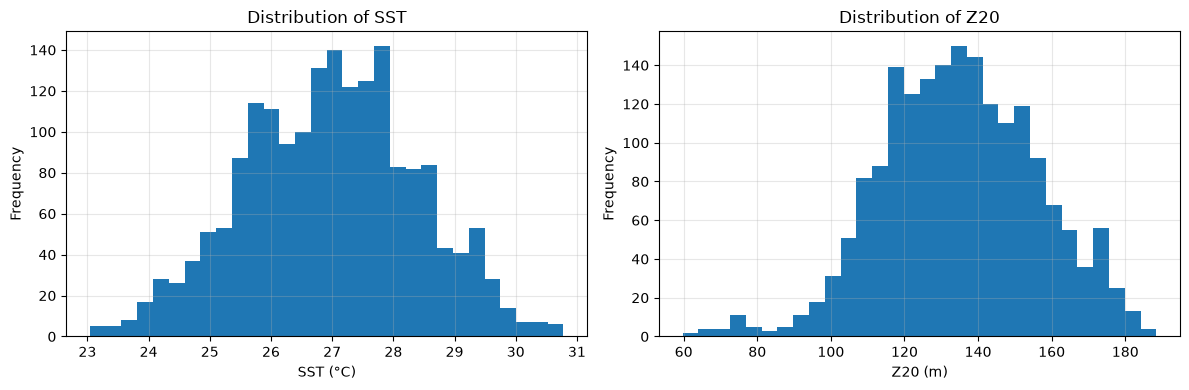

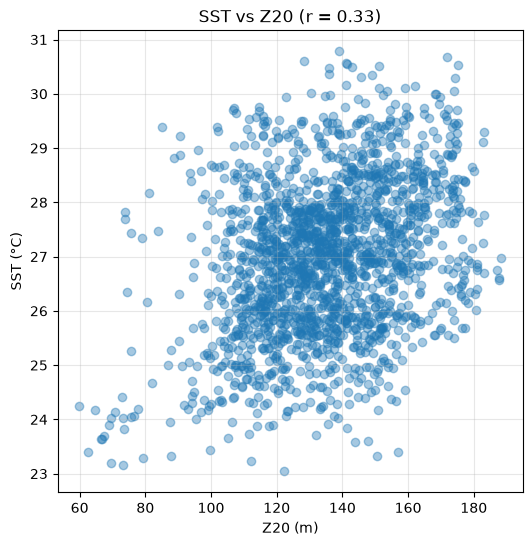

np.float64(0.3262278235811545)

In [11]:
plot_distributions(enso, name="0n155w")

plot_scatter(enso, name="0n155w")

In [12]:
def lag_analysis(enso, max_lag=100, name="enso", save=True):

    # Identify the lag with maximum SST-Z20 correlation
    lags = range(-max_lag, max_lag + 1)

    corrs = [
        enso["sst"].corr(enso["z20"].shift(lag))
        for lag in lags
    ]

    best_idx = np.nanargmax(np.abs(corrs))

    best_lag = lags[best_idx]
    best_corr = corrs[best_idx]

    plt.figure(figsize=(8,4))

    plt.plot(lags,corrs)

    plt.axvline(
        best_lag,
        color="red",
        linestyle="--",
        label=f"Peak lag = {best_lag}"
    )

    plt.axhline(0,color="black",linestyle=":")

    plt.xlabel("Lag (5-day intervals)")
    plt.ylabel("Correlation")
    plt.title("Lag Correlation Between SST and Z20")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    if save:
        plt.savefig(
            IMAGE_DIR / f"{name}_lag_analysis.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return {
        "best_lag": best_lag,
        "lag_days": best_lag * 5,
        "best_corr": round(best_corr,3)
    }

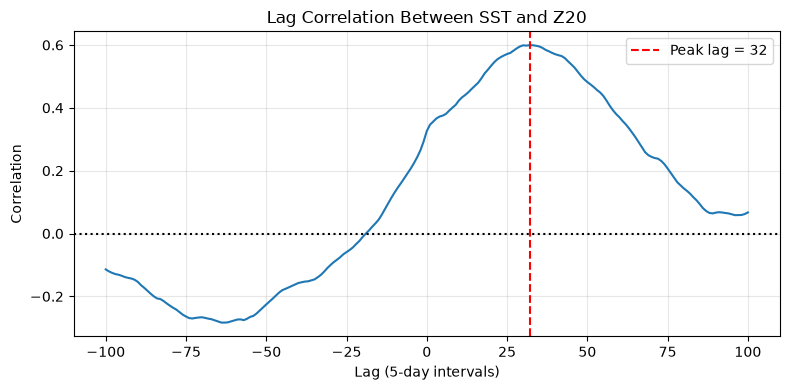

{'best_lag': 32, 'lag_days': 160, 'best_corr': np.float64(0.599)}

In [13]:
lag_analysis(enso, name="enso")

In [14]:
def spectral_analysis(series, name="enso", save=True):

    # Identify dominant oscillation periods
    freqs, power = periodogram(series, fs=1/5)

    plt.figure(figsize=(9,4))

    plt.plot(
        1/freqs[1:],
        power[1:],
        linewidth=1.5
    )

    plt.xlim(0,3000)

    plt.xlabel("Period (days)")
    plt.ylabel("Power")
    plt.title(f"Power Spectrum of {name}")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    if save:
        plt.savefig(
            IMAGE_DIR / f"{name}_spectrum.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    peaks, _ = find_peaks(power)

    top = pd.DataFrame({
        "period_years": (1/freqs[peaks])/365,
        "power": power[peaks]
    })

    top = top.sort_values(
        "power",
        ascending=False
    ).head(10)

    return top, {
        "dominant_period": round(top.iloc[0]["period_years"],2),
        "max_power": round(top.iloc[0]["power"],2)
    }

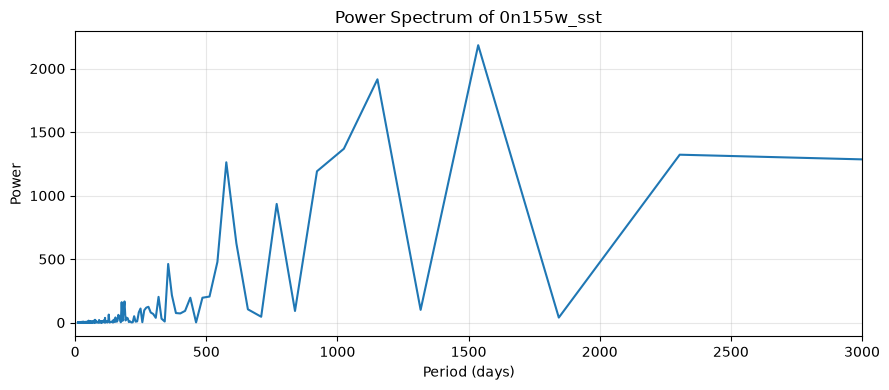

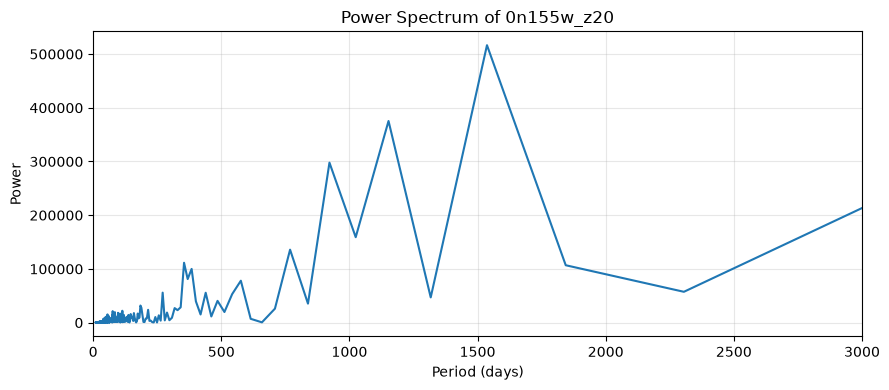

,period_years,power
1,4.210046,2184.041641
2,3.157534,1915.438053
0,6.315068,1322.069666
4,1.578767,1262.264754
3,2.105023,934.282112
6,0.971549,461.745018
7,0.871044,202.805346
5,1.202870,195.928311
13,0.515516,166.842223
14,0.485774,160.819542


In [15]:
sst_peaks, sst_details = spectral_analysis(
    enso["sst_anom"],
    name="0n155w_sst"
)

z20_peaks, z20_details = spectral_analysis(
    enso["z20_anom"],
    name="0n155w_z20"
)

sst_peaks

In [16]:
def run_eda(sst_file, z20_file, name="enso"):

    enso, data = prepare_enso_data(sst_file, z20_file)

    plot_time_series(enso, name=name)

    gaps = check_gaps(enso)

    plot_distributions(enso, name=name)

    corr = plot_scatter(enso, name=name)

    lag = lag_analysis(enso, name=name)

    sst_peaks, sst = spectral_analysis(
        enso["sst_anom"],
        name=f"{name}_sst"
    )

    z20_peaks, z20 = spectral_analysis(
        enso["z20_anom"],
        name=f"{name}_z20"
    )

    with open(LOG_FILE, "a") as f:

        f.write(f"\n{'='*60}\n")

        f.write(f"Dataset: {name}\n")

        f.write(
            f"Date range: "
            f"{data['start']} → {data['end']}\n"
        )

        f.write(
            f"Observations: "
            f"{data['observations']}\n"
        )

        f.write(
            f"SST missing: "
            f"{data['sst_missing']}\n"
        )

        f.write(
            f"Z20 missing: "
            f"{data['z20_missing']}\n"
        )

        f.write(
            f"Correlation: "
            f"{corr:.3f}\n"
        )

        f.write(
            f"Best lag: "
            f"{lag['best_lag']} "
            f"({lag['lag_days']} days)\n"
        )

        f.write(
            f"Best lag correlation: "
            f"{lag['best_corr']}\n"
        )

        f.write(
            f"SST dominant period: "
            f"{sst['dominant_period']} years\n"
        )

        f.write(
            f"Z20 dominant period: "
            f"{z20['dominant_period']} years\n"
        )

        f.write(
            f"Gaps >30 days: "
            f"{len(gaps)}\n"
        )

    return {
        "data": data,
        "gaps": gaps,
        "corr": corr,
        "lag": lag,
        "sst": sst,
        "z20": z20,
        "sst_peaks": sst_peaks,
        "z20_peaks": z20_peaks
    }

In [17]:
# results = run_eda( "data/sst/sst0n170w_5day.ascii.gz",  "data/z20/iso0n170w_5day.ascii.gz", name="0n170w" )

# results

In [18]:
'''


core_locations = [
    "0n140w",
    "0n155w",
    "0n170w",
    "0n180w",
    "0n165e",
]

fig, axs = plt.subplots(
    5,
    2,
    figsize=(14, 14),
    sharex=True,
)

for i, loc in enumerate(core_locations):

    enso, _ = prepare_enso_data(
        f"data/sst/sst{loc}_5day.ascii.gz",
        f"data/z20/iso{loc}_5day.ascii.gz",
    )

    axs[i, 0].plot(
        enso["date"],
        enso["sst"],
        linewidth=1,
    )

    axs[i, 0].set_title(f"{loc} SST")

    axs[i, 0].set_ylabel("°C")

    axs[i, 0].grid(True)

    axs[i, 1].plot(
        enso["date"],
        enso["z20"],
        linewidth=1,
    )

    axs[i, 1].set_title(f"{loc} Z20")

    axs[i, 1].set_ylabel("m")

    axs[i, 1].grid(True)

axs[-1, 0].set_xlabel("Year")

axs[-1, 1].set_xlabel("Year")

plt.suptitle(
    "SST and Z20 Time Series Across Selected Equatorial Pacific Locations"
)

plt.tight_layout()

plt.savefig(
    "outputs/images/enso/time_series_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

'''

'\n\n\ncore_locations = [\n    "0n140w",\n    "0n155w",\n    "0n170w",\n    "0n180w",\n    "0n165e",\n]\n\nfig, axs = plt.subplots(\n    5,\n    2,\n    figsize=(14, 14),\n    sharex=True,\n)\n\nfor i, loc in enumerate(core_locations):\n\n    enso, _ = prepare_enso_data(\n        f"data/sst/sst{loc}_5day.ascii.gz",\n        f"data/z20/iso{loc}_5day.ascii.gz",\n    )\n\n    axs[i, 0].plot(\n        enso["date"],\n        enso["sst"],\n        linewidth=1,\n    )\n\n    axs[i, 0].set_title(f"{loc} SST")\n\n    axs[i, 0].set_ylabel("°C")\n\n    axs[i, 0].grid(True)\n\n    axs[i, 1].plot(\n        enso["date"],\n        enso["z20"],\n        linewidth=1,\n    )\n\n    axs[i, 1].set_title(f"{loc} Z20")\n\n    axs[i, 1].set_ylabel("m")\n\n    axs[i, 1].grid(True)\n\naxs[-1, 0].set_xlabel("Year")\n\naxs[-1, 1].set_xlabel("Year")\n\nplt.suptitle(\n    "SST and Z20 Time Series Across Selected Equatorial Pacific Locations"\n)\n\nplt.tight_layout()\n\nplt.savefig(\n    "outputs/images/enso/time_s

In [19]:
''' 
fig, axs = plt.subplots( 5, 1, figsize=(15, 18), sharex=True, )

for i, loc in enumerate(core_locations):

    enso, _ = prepare_enso_data(
        f"data/sst/sst{loc}_5day.ascii.gz",
        f"data/z20/iso{loc}_5day.ascii.gz",
    )

    ax2 = axs[i].twinx()

    sst_line = axs[i].plot(
        enso["date"],
        enso["sst"],
        linewidth=1,
        linestyle="-",
        label="SST",
    )

    z20_line = ax2.plot(
        enso["date"],
        enso["z20"],
        linewidth=1,
        label="Z20",
        linestyle="--",
        color="orange",
    )

    axs[i].set_title(loc)

    axs[i].set_ylabel("SST (°C)")

    ax2.set_ylabel("Z20 (m)")

    axs[i].grid(True)

    lines = sst_line + z20_line

    labels = [line.get_label() for line in lines]

    axs[i].legend(
        lines,
        labels,
        loc="upper right",
    )

axs[-1].set_xlabel("Year")

plt.suptitle(
    "SST and Z20 Time Series Across Selected Equatorial Pacific Locations"
)

plt.tight_layout()

plt.savefig(
    "outputs/images/enso/time_series_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
'''

' \nfig, axs = plt.subplots( 5, 1, figsize=(15, 18), sharex=True, )\n\nfor i, loc in enumerate(core_locations):\n\n    enso, _ = prepare_enso_data(\n        f"data/sst/sst{loc}_5day.ascii.gz",\n        f"data/z20/iso{loc}_5day.ascii.gz",\n    )\n\n    ax2 = axs[i].twinx()\n\n    sst_line = axs[i].plot(\n        enso["date"],\n        enso["sst"],\n        linewidth=1,\n        linestyle="-",\n        label="SST",\n    )\n\n    z20_line = ax2.plot(\n        enso["date"],\n        enso["z20"],\n        linewidth=1,\n        label="Z20",\n        linestyle="--",\n        color="orange",\n    )\n\n    axs[i].set_title(loc)\n\n    axs[i].set_ylabel("SST (°C)")\n\n    ax2.set_ylabel("Z20 (m)")\n\n    axs[i].grid(True)\n\n    lines = sst_line + z20_line\n\n    labels = [line.get_label() for line in lines]\n\n    axs[i].legend(\n        lines,\n        labels,\n        loc="upper right",\n    )\n\naxs[-1].set_xlabel("Year")\n\nplt.suptitle(\n    "SST and Z20 Time Series Across Selected Equator

In [20]:

''' 
all_results = {}

for loc in core_locations:

    print(f"For location : {loc} ")

    all_results[loc] = run_eda(
        f"data/sst/sst{loc}_5day.ascii.gz",
        f"data/z20/iso{loc}_5day.ascii.gz",
        name=loc,
    )
    print(50*"=-=")

print(f"Completed {len(all_results)} locations")
'''

' \nall_results = {}\n\nfor loc in core_locations:\n\n    print(f"For location : {loc} ")\n\n    all_results[loc] = run_eda(\n        f"data/sst/sst{loc}_5day.ascii.gz",\n        f"data/z20/iso{loc}_5day.ascii.gz",\n        name=loc,\n    )\n    print(50*"=-=")\n\nprint(f"Completed {len(all_results)} locations")\n'

In [21]:
'''ArithmeticError
spectral_summary = pd.DataFrame([
    {
        "Location": loc,
        "SST Period (years)": res["sst"]["dominant_period"],
        "Z20 Period (years)": res["z20"]["dominant_period"],
    }

    for loc, res in all_results.items()
])

spectral_summary

'''

'ArithmeticError\nspectral_summary = pd.DataFrame([\n    {\n        "Location": loc,\n        "SST Period (years)": res["sst"]["dominant_period"],\n        "Z20 Period (years)": res["z20"]["dominant_period"],\n    }\n\n    for loc, res in all_results.items()\n])\n\nspectral_summary\n\n'